# HR-Bench Result Visualization
可视化 DeepEyes 在 HR-Bench 上的推理过程：原图 + bbox 裁切 + 对话流程

In [7]:
import os
import json
import re
import base64
import io
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from IPython.display import display, HTML

# ========== 配置 ==========
DATA_DIR = '/mdr5/user/quantaalpha/hutu/DeepEyes/data/HR-Bench'
RESULT_DIR = '/mdr5/user/quantaalpha/hutu/DeepEyes/results/HR-Bench/deepeyes'
TEST_TYPE = 'hr_bench_4k'  # 'hr_bench_4k' or 'hr_bench_8k'
MODEL_NAME = 'deepeyes'

In [8]:
# 加载数据集（获取原图）和结果
tsv_path = os.path.join(DATA_DIR, f'{TEST_TYPE}.tsv')
result_path = os.path.join(RESULT_DIR, f'result_{TEST_TYPE}_{MODEL_NAME}.jsonl')

df = pd.read_csv(tsv_path, sep='\t')
print(f'Dataset: {len(df)} samples')

with open(result_path, 'r') as f:
    results = [json.loads(line) for line in f]
print(f'Results: {len(results)} samples')

# 按 question 建立索引，用于匹配原图
q2row = {}
for i, row in df.iterrows():
    q2row[row['question']] = i

Dataset: 800 samples
Results: 800 samples


In [3]:
IMAGE_FACTOR = 28
MIN_PIXELS = 4 * 28 * 28
MAX_PIXELS = 16384 * 28 * 28

def smart_resize(height, width, factor=IMAGE_FACTOR, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS):
    import math
    h_bar = max(factor, round(height / factor) * factor)
    w_bar = max(factor, round(width / factor) * factor)
    if h_bar * w_bar > max_pixels:
        beta = math.sqrt((height * width) / max_pixels)
        h_bar = math.floor(height / beta / factor) * factor
        w_bar = math.floor(width / beta / factor) * factor
    elif h_bar * w_bar < min_pixels:
        beta = math.sqrt(min_pixels / (height * width))
        h_bar = math.ceil(height * beta / factor) * factor
        w_bar = math.ceil(width * beta / factor) * factor
    return h_bar, w_bar

def map_bbox_to_original(bbox, ori_w, ori_h):
    """Map bbox from model's resized coordinate space back to original image.
    
    eval code does: smart_resize(ori_width, ori_height) -- note width as height!
    Model sees the resized image, outputs bbox in that space.
    We need to scale back to original.
    """
    resize_w, resize_h = smart_resize(ori_w, ori_h)  # same bug as eval code
    scale_w = ori_w / resize_w
    scale_h = ori_h / resize_h
    x1, y1, x2, y2 = bbox
    return [int(x1 * scale_w), int(y1 * scale_h), int(x2 * scale_w), int(y2 * scale_h)]

def decode_image(base64_str):
    """Decode base64 string to PIL Image"""
    img_data = base64.b64decode(base64_str)
    return Image.open(io.BytesIO(img_data)).convert('RGB')

def extract_tool_calls(text):
    """Extract bbox from <tool_call> in assistant message"""
    bboxes = []
    tc_matches = re.findall(r'<tool_call>\s*(.*?)\s*(?:</tool_call>|$)', text, re.DOTALL)
    for tc in tc_matches:
        try:
            call = json.loads(tc.strip())
            if 'arguments' in call and 'bbox_2d' in call['arguments']:
                bbox = call['arguments']['bbox_2d']
                label = call['arguments'].get('label', '')
                bboxes.append({'bbox': bbox, 'label': label})
        except:
            pass
    return bboxes

def extract_think(text):
    """Extract <think> content"""
    m = re.search(r'<think>(.*?)</think>', text, re.DOTALL)
    return m.group(1).strip() if m else ''

def extract_answer(text):
    """Extract <answer> content"""
    m = re.search(r'<answer>(.*?)</answer>', text, re.DOTALL)
    return m.group(1).strip() if m else ''


In [4]:
def rule_match(answer, pred_ans):
    """Rule-based accuracy for multiple choice"""
    pred = pred_ans.strip()
    if not pred:
        return 0.0
    # e.g. 'A. Blue', 'B', 'C、xxx'
    if pred[0] in 'ABCDEF' and (len(pred) == 1 or pred[1] in '.、 ,'):
        return 1.0 if pred[0] == answer else 0.0
    if answer in pred:
        return 1.0
    return 0.0

# 计算规则准确率
by_cat = {}
for r in results:
    acc = rule_match(r['answer'], r['pred_ans'])
    r['rule_acc'] = acc  # 写入方便后续筛选
    cat = r['category']
    if cat not in by_cat:
        by_cat[cat] = [0, 0]
    by_cat[cat][0] += acc
    by_cat[cat][1] += 1

total_correct = sum(v[0] for v in by_cat.values())
total = sum(v[1] for v in by_cat.values())
print(f'Overall Accuracy: {int(total_correct)}/{total} = {total_correct/total*100:.1f}%')
for cat, (c, t) in sorted(by_cat.items()):
    print(f'  {cat}: {int(c)}/{t} = {c/t*100:.1f}%')

# 统计 tool use
tool_use_cnt = 0
multi_turn_cnt = 0
for r in results:
    asst_msgs = [m for m in r['pred_output'] if m['role'] == 'assistant']
    has_tool = any('<tool_call>' in (m['content'] if isinstance(m['content'], str) else '') for m in asst_msgs)
    if has_tool:
        tool_use_cnt += 1
    if len(asst_msgs) > 1:
        multi_turn_cnt += 1
print(f'Tool use: {tool_use_cnt}/{len(results)} ({tool_use_cnt/len(results)*100:.1f}%)')
print(f'Multi-turn: {multi_turn_cnt}/{len(results)} ({multi_turn_cnt/len(results)*100:.1f}%)')


Overall Accuracy: 584/800 = 73.0%
  cross: 223/400 = 55.8%
  single: 361/400 = 90.2%
Tool use: 796/800 (99.5%)
Multi-turn: 794/800 (99.2%)


In [5]:
def visualize_sample(idx, show_crop=True):
    """Visualize the full inference process of sample idx"""
    r = results[idx]
    question = r['question']
    answer = r['answer']
    answer_str = r.get('answer_str', '')
    pred_ans = r['pred_ans']
    category = r['category']
    status = r.get('status', '?')
    acc = r.get('rule_acc', rule_match(r['answer'], r['pred_ans']))
    
    # Get original image
    row_idx = q2row.get(question)
    if row_idx is not None:
        ori_img = decode_image(df.iloc[row_idx]['image'])
    else:
        print(f'[WARN] Cannot find original image for question: {question[:80]}')
        ori_img = None
    
    acc_str = 'O' if acc == 1.0 else ('X' if acc == 0.0 else '?')
    print(f'===== Sample {idx} | {category} | {status} | {acc_str} =====')
    print(f'Question: {question}')
    print(f'GT Answer: {answer}. {answer_str}')
    print(f'Pred Answer: {pred_ans}')
    if ori_img:
        ori_w, ori_h = ori_img.size
        rw, rh = smart_resize(ori_w, ori_h)
        print(f'Image: {ori_w}x{ori_h} -> model sees {rw}x{rh} (scale {ori_w/rw:.3f}x, {ori_h/rh:.3f}x)')
    print()
    
    # Collect all bboxes and map to original coordinates
    all_bboxes = []
    for msg in r['pred_output']:
        if msg['role'] == 'assistant':
            content = msg['content'] if isinstance(msg['content'], str) else ''
            bboxes = extract_tool_calls(content)
            all_bboxes.extend(bboxes)
    
    if ori_img is not None and all_bboxes:
        ori_w, ori_h = ori_img.size
        for bb in all_bboxes:
            bb['bbox_orig'] = map_bbox_to_original(bb['bbox'], ori_w, ori_h)
    
    # Show original image + mapped bboxes
    if ori_img is not None:
        fig, ax = plt.subplots(1, 1, figsize=(12, 8))
        ax.imshow(ori_img)
        colors = ['red', 'blue', 'green', 'orange', 'purple']
        for i, bb in enumerate(all_bboxes):
            x1, y1, x2, y2 = bb['bbox_orig']
            color = colors[i % len(colors)]
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                     linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-5, f"T{i+1}: {bb['label']}", color=color, fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
        ax.set_title(f'Original Image ({ori_img.size[0]}x{ori_img.size[1]}) + Mapped BBoxes')
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    
    # Show cropped images (from original coords)
    if show_crop and ori_img is not None and all_bboxes:
        n = len(all_bboxes)
        fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
        if n == 1:
            axes = [axes]
        for i, bb in enumerate(all_bboxes):
            x1, y1, x2, y2 = bb['bbox_orig']
            crop = ori_img.crop((x1, y1, x2, y2))
            raw = bb['bbox']
            axes[i].imshow(crop)
            axes[i].set_title(f"T{i+1}: {bb['label']}\nmodel:[{raw[0]},{raw[1]},{raw[2]},{raw[3]}]\norig:[{x1},{y1},{x2},{y2}]")
            axes[i].axis('off')
        plt.tight_layout()
        plt.show()
    
    # Print conversation
    print('--- Conversation ---')
    turn = 0
    for msg in r['pred_output']:
        role = msg['role']
        if role == 'system':
            continue
        content = msg['content'] if isinstance(msg['content'], str) else '[multimodal]'
        if role == 'assistant':
            turn += 1
            think = extract_think(content)
            ans = extract_answer(content)
            bboxes = extract_tool_calls(content)
            print(f'\n[Assistant Turn {turn}]')
            if think:
                print(f'  Think: {think[:300]}')
            if bboxes:
                for bb in bboxes:
                    print(f'  Tool Call: bbox={bb["bbox"]}, label="{bb["label"]}"')
            if ans:
                print(f'  Answer: {ans}')
    print()


===== Sample 8 | cross | success | O =====
Question: Is the mailbox on the left or right side of the woman?
GT Answer: A. Right
Pred Answer: A. Right
Image: 4032x4032 -> model sees 3584x3584 (scale 1.125x, 1.125x)



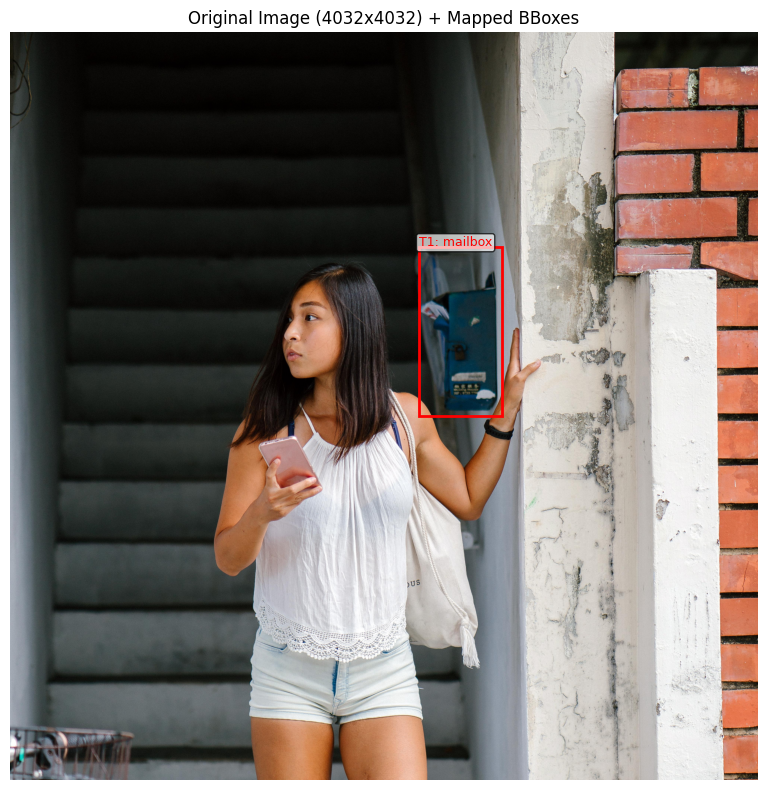

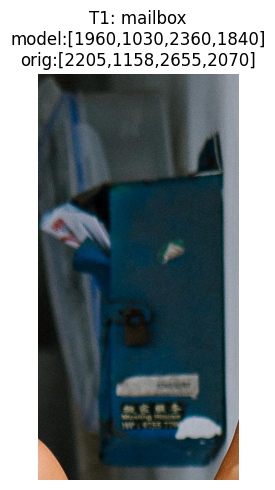

--- Conversation ---

[Assistant Turn 1]
  Think: The mailbox is located to the right of the woman. To confirm this, I can use the image_zoom_in_tool to zoom in on the area around the mailbox and the woman to verify its position.
  Tool Call: bbox=[1960, 1030, 2360, 1840], label="mailbox"

[Assistant Turn 2]
  Think: The mailbox is indeed to the right of the woman, as confirmed by the zoomed-in image. Therefore, the correct answer is A. Right.
  Answer: A. Right



In [6]:
# 看第 0 个样本
visualize_sample(8)

In [ ]:
# 筛选错误样本（基于规则匹配）
error_indices = [i for i, r in enumerate(results) if r.get('rule_acc', 1.0) == 0.0]
print(f'Error samples: {len(error_indices)}')
print(f'First 10 error indices: {error_indices[:10]}')


In [ ]:
# 看某个错误样本
if error_indices:
    visualize_sample(error_indices[0])

In [ ]:
# 自由查看任意样本
# visualize_sample(42)